# Data Sanity Check


In [2]:
import pandas as pd


# --- Load ---
rain_df = pd.read_csv("kanker_daily_rain_1997-2024.csv")

# --- Clean column names (whitespace + weird hidden characters) ---
rain_df.columns = (
    rain_df.columns
    .astype(str)
    .str.replace("\ufeff", "", regex=False)   # removes BOM if present
    .str.strip()
)

# --- Find / recover the Date column robustly ---
# 1) If Date is the index, reset it
if rain_df.index.name and rain_df.index.name.strip().lower() == "date":
    rain_df = rain_df.reset_index()

# 2) If there is no exact "Date" column, try to detect a date-like column
if "Date" not in rain_df.columns:
    # look for any column whose name contains 'date' or 'time'
    date_candidates = [c for c in rain_df.columns if "date" in c.lower() or "time" in c.lower()]

    if len(date_candidates) == 1:
        rain_df = rain_df.rename(columns={date_candidates[0]: "Date"})
    elif len(date_candidates) > 1:
        raise KeyError(
            f"Multiple possible date columns found: {date_candidates}. "
            "Rename the correct one to 'Date'."
        )
    else:
        # last resort: maybe the first column is actually the date column
        first_col = rain_df.columns[0]
        sample = rain_df[first_col].astype(str).head(5).tolist()
        raise KeyError(
            f"No 'Date' column found. Columns are: {rain_df.columns.tolist()}\n"
            f"First column is '{first_col}' with sample values: {sample}\n"
            "Fix: rename your date column to 'Date' or reset_index() if it's the index."
        )

# --- Parse Date safely ---
rain_df["Date"] = pd.to_datetime(rain_df["Date"], dayfirst=True, errors="coerce")

# --- Sanity checks ---
if rain_df["Date"].isna().any():
    bad_rows = rain_df.loc[rain_df["Date"].isna(), ["Date"]].head(10)
    raise ValueError(
        "Some Date values could not be parsed into datetimes.\n"
        "This usually means inconsistent formatting or non-date text.\n"
        f"Examples of problematic rows:\n{bad_rows}"
    )

# Optional: sort by date to keep downstream logic consistent
rain_df = rain_df.sort_values("Date").reset_index(drop=True)

# Rain Threshold Finder


In [3]:
# -------------------------------------------------------------------
# NEW THRESHOLD FINDER SCRIPT
# -------------------------------------------------------------------
import pandas as pd
import numpy as np

# --- 1. Define File Names and Parameters ---
DAILY_RAIN_FILE = 'kanker_daily_rain_1997-2024.csv'
DATE_COLUMN_NAME = 'TIME' 

# --- 2. Window Parameters ---
START_MONTH = 7
START_DAY = 9
END_MONTH = 8
END_DAY = 7

print("--- Running New Threshold Finder ---")

# --- 3. Load Data ---
try:
    rain_df = pd.read_csv(DAILY_RAIN_FILE)
    rain_df = rain_df.rename(columns={DATE_COLUMN_NAME: 'Date', 'Mean_Rainfall_mm': 'Rainfall'})
    try:
        rain_df['Date'] = pd.to_datetime(rain_df['Date'], dayfirst=True)
    except Exception:
        rain_df['Date'] = pd.to_datetime(rain_df['Date'])
    rain_df = rain_df.dropna(subset=['Rainfall'])
    print("Daily data loaded successfully.")
except Exception as e:
    print(f"Error loading data: {e}")

# --- 4. Isolate Seasonal Data ---
window_mask = (rain_df['Date'].dt.month == START_MONTH) & (rain_df['Date'].dt.day >= START_DAY) | \
              (rain_df['Date'].dt.month == END_MONTH) & (rain_df['Date'].dt.day <= END_DAY)
seasonal_df = rain_df[window_mask].copy()

# --- 5. Analyze Rainfall Distribution ---
# First, let's get *only* the days with *any* rain (Rainfall > 0)
rainy_days_data = seasonal_df[seasonal_df['Rainfall'] > 0]['Rainfall']

print(f"\nTotal seasonal days (July 9 - Aug 7): {len(seasonal_df)}")
print(f"Total days with ANY rain (Rain > 0): {len(rainy_days_data)}")

# --- 6. Calculate Percentile-Based Thresholds ---
# This will show us the distribution of the "rainy" days
p10 = np.percentile(rainy_days_data, 10)
p20 = np.percentile(rainy_days_data, 20)
p25 = np.percentile(rainy_days_data, 25)
p30 = np.percentile(rainy_days_data, 30)
p50 = np.percentile(rainy_days_data, 50) # The median

print("\n--- Percentiles for 'Rainy' Days (Rain > 0) ---")
print(f"  10th percentile (p10): {p10:.2f} mm")
print(f"  20th percentile (p20): {p20:.2f} mm")
print(f"  25th percentile (p25): {p25:.2f} mm")
print(f"  30th percentile (p30): {p30:.2f} mm")
print(f"  50th percentile (Median): {p50:.2f} mm")

print("\n--- RECOMMENDATION ---")
print("To separate 'trace rain' from 'real rain', choose a threshold from this list.")
print(f"For example, if p25 = 4.8 mm, this means 25% of all 'rainy' days")
print("are just 'drizzle' (less than 4.8 mm).")
print(f"Let's try using the 25th percentile ({p25:.2f} mm) as our new RAIN_THRESHOLD.")

--- Running New Threshold Finder ---
Daily data loaded successfully.

Total seasonal days (July 9 - Aug 7): 810
Total days with ANY rain (Rain > 0): 790

--- Percentiles for 'Rainy' Days (Rain > 0) ---
  10th percentile (p10): 0.83 mm
  20th percentile (p20): 1.90 mm
  25th percentile (p25): 2.49 mm
  30th percentile (p30): 3.36 mm
  50th percentile (Median): 7.96 mm

--- RECOMMENDATION ---
To separate 'trace rain' from 'real rain', choose a threshold from this list.
For example, if p25 = 4.8 mm, this means 25% of all 'rainy' days
are just 'drizzle' (less than 4.8 mm).
Let's try using the 25th percentile (2.49 mm) as our new RAIN_THRESHOLD.


# HBA

In [4]:
# -------------------------------------------------------------------
# CHAPTER 3.3.1: MODEL 1 - HISTORICAL BURN ANALYSIS (HBA) - DROUGHT ONLY
# -------------------------------------------------------------------
import pandas as pd
import numpy as np

# --- 1. Define File Names and Parameters ---
FINAL_INDEX_FILE = 'final_index_series.csv'

# --- Derivative Parameters ---
# DROUGHT PROTECTION ONLY (Put Option)
# We set a lower strike. If rainfall is below this, the farmer gets paid.
STRIKE_PERCENTILE = 0.50  # 50th percentile (Protects against the driest 50% of years)

TICK_VALUE = 1000  # Rs.1000 per mm of rainfall deficit
DISCOUNT_RATE = 0.065  # 6.5% annual risk-free rate
TIME_TO_MATURITY_T = 1 

print("Parameters set.")

# --- 2. Load the Final Index Data ---
print(f"Loading final index data from: {FINAL_INDEX_FILE}...")
try:
    index_df = pd.read_csv(FINAL_INDEX_FILE)
    # We will use the 'Index_Value_mm' column
    R = index_df['Index_Value_mm']
    print("Data loaded successfully.")
    print(f"Loaded {len(R)} years of index data.")
except FileNotFoundError:
    print(f"--- ERROR: File not found: {FINAL_INDEX_FILE} ---")
except KeyError:
    print(f"--- ERROR: Column 'Index_Value_mm' not found in file. ---")

# --- 3. Define Strike ---
# Calculate the drought strike level from the historical data
K_drought_strike = np.percentile(R, STRIKE_PERCENTILE * 100)

print(f"\nCalculating strike based on {len(R)} years of data...")
print(f"  Drought Strike (K) at {STRIKE_PERCENTILE*100}th percentile: {K_drought_strike:.2f} mm")

# --- 4. Calculate Historical Payoffs (Vectorized) ---
print("Calculating historical payoffs for each year...")

# Payoff = max(Strike - Index, 0) * Tick
# This creates a payout ONLY if rainfall is BELOW the strike
payoffs = np.maximum(K_drought_strike - R, 0) * TICK_VALUE

# Add this to our dataframe to see the results
index_df['Historical_Payoff'] = payoffs

print("Payoff calculation complete.")
print("\nDataFrame with calculated historical payoffs:")
print(index_df)

# --- 5. Calculate the Final HBA Price ---
# The HBA price is the simple average of all historical payoffs...
average_payoff = payoffs.mean()

# ...discounted to present value.
hba_price = average_payoff * np.exp(-DISCOUNT_RATE * TIME_TO_MATURITY_T)

# --- 6. Final Result ---
print("\n--- !!! FINAL HBA PRICING RESULT (DROUGHT ONLY) !!! ---")
print(f"  Average Historical Payoff (Expected Loss): Rs.{average_payoff:.2f}")
print(f"  Discounted HBA Price (Actuarial Premium): Rs.{hba_price:.2f}")

Parameters set.
Loading final index data from: final_index_series.csv...
Data loaded successfully.
Loaded 25 years of index data.

Calculating strike based on 25 years of data...
  Drought Strike (K) at 50.0th percentile: 357.26 mm
Calculating historical payoffs for each year...
Payoff calculation complete.

DataFrame with calculated historical payoffs:
    Year  Index_Value_mm  Historical_Payoff
0   1998      302.446112       54812.385479
1   1999      364.210995           0.000000
2   2000      308.890435       48368.062254
3   2001      435.131085           0.000000
4   2002      204.792493      152466.004126
5   2003      548.448104           0.000000
6   2004      377.376597           0.000000
7   2005      357.258497           0.000000
8   2006      588.623738           0.000000
9   2007      398.410458           0.000000
10  2008      317.588911       39669.586439
11  2009      339.620095       17638.402220
12  2010      543.960709           0.000000
13  2011      294.891402    

# Backtest

--- Backtest Script (Drought Protection Only) ---
Parameters set. Loading data...
Data merged. 25 total years.
Training on 18 years. Testing on 7 years.

--- Calculating All Parameters on TRAINING Data ---
  Drought Strike (Train-set): K=370.79 mm
  Calibrated Drought Tick: q=Rs.97.39/mm

Rescaling premium by tick factor x0.0974...
  Final HBA Premium (Actuarial): Rs.3,527.06

--- Running Backtest on TEST Data (Out-of-Sample) ---
Backtest simulation complete.

--- !!! FINAL OUT-OF-SAMPLE BACKTEST RESULTS !!! ---
|           |   Mean Revenue |   Std Dev |   Min Revenue (Worst Year) |   Ederington_Effectiveness |
|:----------|---------------:|----------:|---------------------------:|---------------------------:|
| No_Hedge  |      42,786.80 | 12,031.61 |                  27,724.10 |                       0.00 |
| HBA_Hedge |      45,952.56 | 11,560.04 |                  29,222.30 |                       0.08 |

Plotting Revenue Comparison...


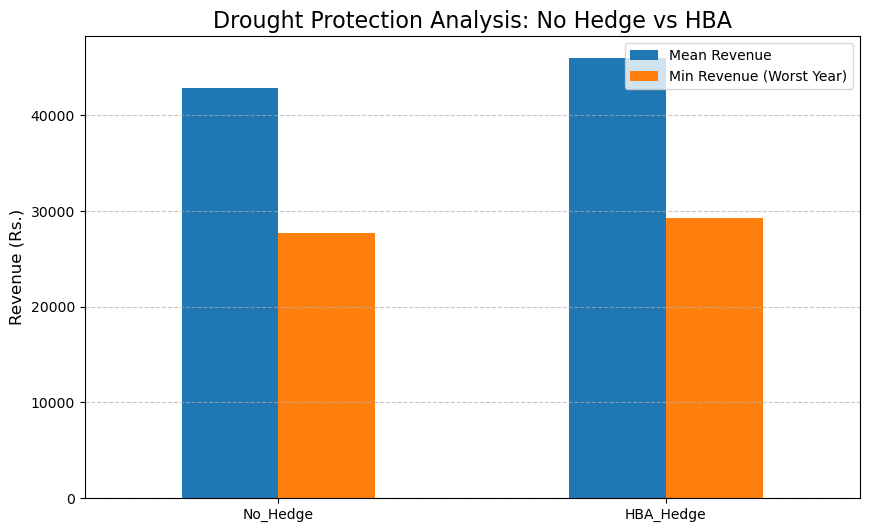


Total time taken: 0.38 seconds


In [5]:
# -------------------------------------------------------------------
# CHAPTER 3.4.3: THE FINANCIAL BACKTEST - DROUGHT ONLY (HBA)
# -------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls # Non-negative least squares
import time

print("--- Backtest Script (Drought Protection Only) ---")
start_time = time.time()

# --- 1. Define File Names and Parameters ---
FINAL_INDEX_FILE = 'final_index_series.csv'
YIELD_FILE = 'kanker_yield.csv'
YIELD_FILE_DETRENDED = 'kanker_yield_detrended.csv'

# --- Economic Parameters ---
PRICE_OF_RICE = 21830  # Rs/Tonne (MSP for 2023-24)
SPLIT_YEAR = 2016      # The year our TEST set begins

# --- Raw Model Prices ---
# (Input the price you got from the HBA step above manually if needed, 
# but here we use the variable concept)
TICK_OLD = 1000.0        
# REPLACE THIS VALUE with the exact output from Step 1 if you want precision
HBA_PRICE_raw = 36214.03 

# --- Derivative Parameters ---
STRIKE_PERCENTILE = 0.50  # 50th percentile Drought Strike

print("Parameters set. Loading data...")

# --- 2. Load and Split Data ---
try:
    index_df = pd.read_csv(FINAL_INDEX_FILE)
    yield_df = pd.read_csv(YIELD_FILE)
    yield_detrended_df = pd.read_csv(YIELD_FILE_DETRENDED)
except FileNotFoundError as e:
    print(f"--- ERROR: {e} ---")

master_df = pd.merge(index_df, yield_df, on='Year')
master_df = pd.merge(master_df, yield_detrended_df, on='Year')
print(f"Data merged. {len(master_df)} total years.")

train_df = master_df[master_df['Year'] < SPLIT_YEAR].copy()
test_df = master_df[master_df['Year'] >= SPLIT_YEAR].copy()
print(f"Training on {len(train_df)} years. Testing on {len(test_df)} years.")

# --- 3. Calculate Parameters on TRAINING Data ONLY ---
print("\n--- Calculating All Parameters on TRAINING Data ---")

# 3a. Calculate Drought Strike
K_drought = np.percentile(train_df['Index_Value_mm'], STRIKE_PERCENTILE * 100)
print(f"  Drought Strike (Train-set): K={K_drought:.2f} mm")

# 3b. Calculate Optimal Tick "Economic Hedge"
# We regress Yield Loss (in Rs) against Rainfall Deficit (in mm)
# Formula: Yield_Loss ~ q * max(Strike - Rain, 0)
R_tr = train_df['Index_Value_mm'].values
dry_mm_tr = np.maximum(K_drought - R_tr, 0.0)

# Target: We want to cover the money lost due to bad yield
# Yield_Detrended is deviation from normal. Negative means loss.
# We flip the sign so loss is a positive number we want to pay out.
y_loss_rs_tr = -PRICE_OF_RICE * train_df['Yield_Detrended'].values
# Only care about years where yield was actually lower than trend
y_loss_rs_tr = np.maximum(y_loss_rs_tr, 0)

# Reshape for regression
X_tr = dry_mm_tr.reshape(-1, 1)

# Solve for q (Tick size)
q_hat, _ = nnls(X_tr, y_loss_rs_tr)
q_opt = q_hat[0]
print(f"  Calibrated Drought Tick: q=Rs.{q_opt:.2f}/mm")

# 3c. Rescale Premiums
# We adjust the raw HBA price based on the ratio of the "Optimal Tick" to the "Old Tick"
scale = q_opt / TICK_OLD

if scale > 0:
    print(f"\nRescaling premium by tick factor x{scale:.4f}...")
    HBA_PREMIUM = HBA_PRICE_raw * scale
else:
    print("\nWarning: Economic tick is zero (No correlation found). Using raw premium.")
    HBA_PREMIUM = HBA_PRICE_raw

print(f"  Final HBA Premium (Actuarial): Rs.{HBA_PREMIUM:,.2f}")

# --- 4. Run Backtest on TEST Data ONLY ---
print("\n--- Running Backtest on TEST Data (Out-of-Sample) ---")

R_te = test_df['Index_Value_mm'].values
# Calculate payout using Train Strike and Optimal Tick
dry_mm_te = np.maximum(K_drought - R_te, 0.0)
test_df['Historical_Payoff_Rs'] = dry_mm_te * q_opt

test_df['Revenue_NoHedge'] = test_df['Yield'] * PRICE_OF_RICE
# Net Revenue = Revenue + Insurance Payout - Premium Paid
test_df['Revenue_HBA'] = test_df['Revenue_NoHedge'] + test_df['Historical_Payoff_Rs'] - HBA_PREMIUM

print("Backtest simulation complete.")

# --- 5. Calculate Final Metrics (on TEST Data) ---
def scenario_metrics(df, label):
    m = {}
    m['Mean Revenue'] = df.mean()
    m['Std Dev'] = df.std(ddof=1)
    m['Min Revenue (Worst Year)'] = df.min()
    return pd.Series(m, name=label)

results = pd.concat([
    scenario_metrics(test_df['Revenue_NoHedge'], 'No_Hedge'),
    scenario_metrics(test_df['Revenue_HBA'], 'HBA_Hedge')
], axis=1).T

base_var = results.loc['No_Hedge', 'Std Dev']**2
results['Ederington_Effectiveness'] = 1.0 - (results['Std Dev']**2 / base_var)

print("\n--- !!! FINAL OUT-OF-SAMPLE BACKTEST RESULTS !!! ---")
print(results.to_markdown(floatfmt=",.2f"))

# --- 6. Plot the Results ---
print("\nPlotting Revenue Comparison...")
ax = results[['Mean Revenue', 'Min Revenue (Worst Year)']].plot(kind='bar', figsize=(10, 6))
plt.title('Drought Protection Analysis: No Hedge vs HBA', fontsize=16)
plt.ylabel('Revenue (Rs.)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('Models_Gem_Drought_HBA_Only_plot_3.png', bbox_inches='tight')
plt.show()

end_time = time.time()
print(f"\nTotal time taken: {end_time - start_time:.2f} seconds")